In [1]:
import anndata

import dtangle

In [2]:
# Load dataset
adata_mix = anndata.read_h5ad("./data/brain_aging_microarray.h5ad")
adata_ref = anndata.read_h5ad("./data/brain_single_cell.h5ad")
adata_mix.var_names_make_unique()
adata_ref.var_names_make_unique()

In [3]:
# Find common genes
common_genes = adata_mix.var_names.intersection(adata_ref.var_names)
adata_mix = adata_mix[:, common_genes].copy()
adata_ref = adata_ref[:, common_genes].copy()

In [4]:
dtangle.deconvolut(
    adata_mix,
    references=adata_ref,
    reference_annotation_col="cell_type",
    data_type="microarray-gene",
    key_added="dtangle_sc",
)

adata_mix.obsm["dtangle_sc"].head()

,Oligodendrocyte precursor cells,Neurons,Neuroblast,Astrocytes,Oligodendrocytes,Microglia
GSM1303144_24M.CEL,0.130750,0.385471,0.157636,0.128135,0.087965,0.110044
GSM1303145_25BF.CEL,0.134050,0.373632,0.158939,0.135272,0.088278,0.109829
GSM1303146_25F.CEL,0.131120,0.372604,0.154251,0.146045,0.091005,0.104975
GSM1303147_26BM.CEL,0.129604,0.356444,0.152652,0.157790,0.091801,0.111709
GSM1303148_26M.CEL,0.129315,0.357495,0.153784,0.141635,0.101902,0.115869


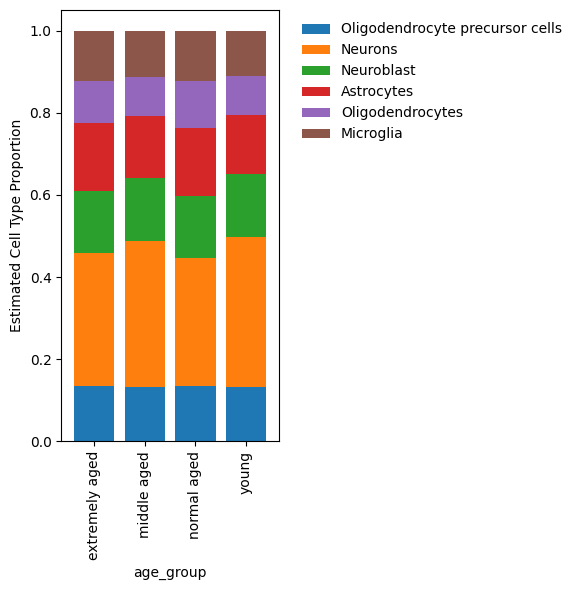

In [5]:
import matplotlib.pyplot as plt

proportions = adata_mix.obsm["dtangle_sc"].copy()
proportions["age_group"] = adata_mix.obs["age_group"].values
proportions = proportions.groupby("age_group", observed=True).mean()
proportions.plot(kind="bar", stacked=True, figsize=(6, 6), width=0.8)
plt.ylabel("Estimated Cell Type Proportion")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

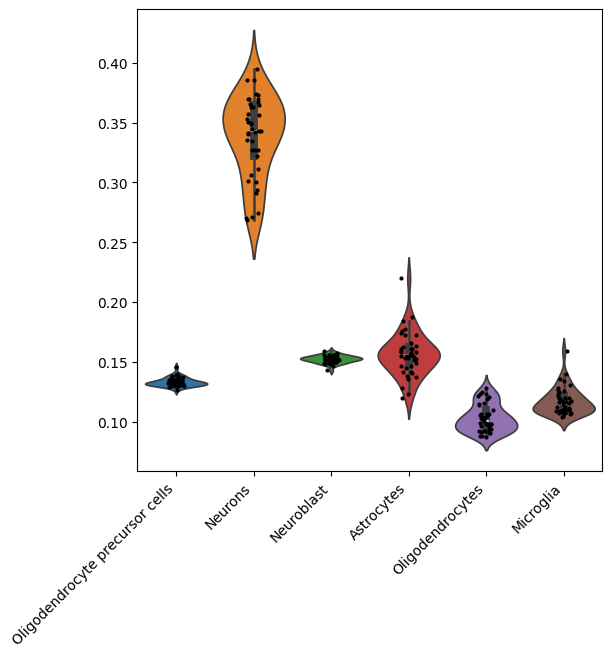

In [6]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(6, 6))
sns.violinplot(adata_mix.obsm["dtangle_sc"], ax=ax)
sns.stripplot(adata_mix.obsm["dtangle_sc"], color="k", size=3, ax=ax)
_ = ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

In [7]:
out = dtangle.differential_proportion(
    adata_mix,
    conds_col="age_group",
    samples_col="sample_name",
    proportions_key="dtangle_sc",
)

In [9]:
out.results[out.results["adjusted_p_values"] < 0.05]

,baseline_props,mean_props_young,mean_props_middle aged,mean_props_normal aged,mean_props_extremely aged,f_statistics,p_values,adjusted_p_values
clusters,,,,,,,,
Oligodendrocyte precursor cells,0.133125,0.131300,0.131599,0.134711,0.135695,3.807588,1.715160e-02,0.017152
Neurons,0.338393,0.365446,0.356696,0.311598,0.323238,13.985982,2.184690e-06,0.000007
Neuroblast,0.152294,0.154895,0.153842,0.149921,0.150500,10.908209,2.257582e-05,0.000045
Astrocytes,0.156216,0.142611,0.150229,0.167350,0.165962,7.917052,2.899043e-04,0.000435
Oligodendrocytes,0.102999,0.095337,0.095355,0.113469,0.101304,16.801103,3.185138e-07,0.000002
Microglia,0.116972,0.110410,0.112279,0.122951,0.123302,5.675187,2.452204e-03,0.002943


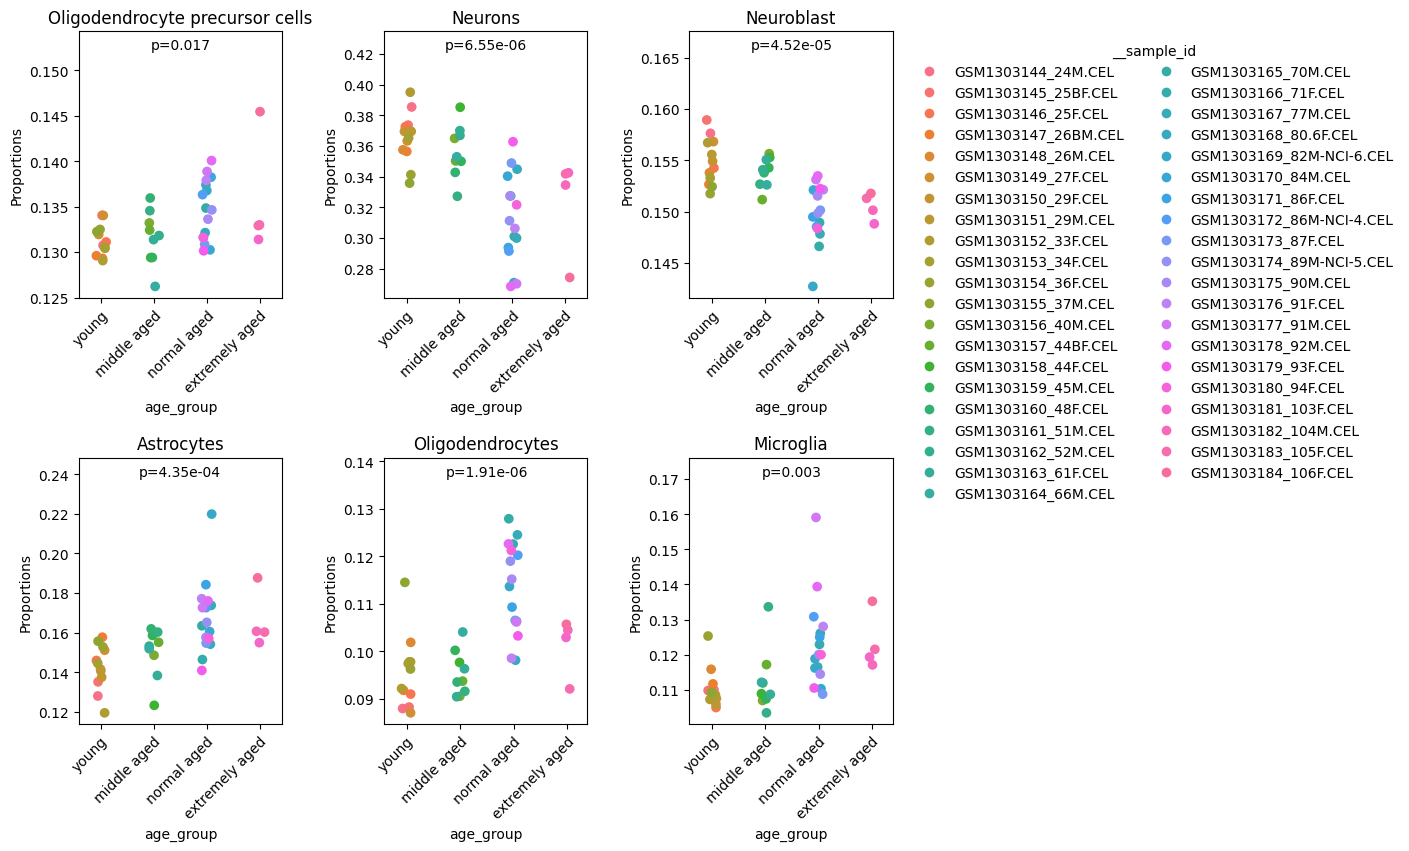

In [8]:
out.plot()